In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from matplotlib.colors import LinearSegmentedColormap

def plot_confusion_matrices(
    conf_mats,
    titles,
    class_names_list,
    cmap=None,
    save_path="confusion_matrices.png"
):
    """
    Three confusion matrices side-by-side with ONE shared colorbar on a dedicated axis.
    - Only the leftmost matrix has the 'Actual' y-axis label.
    - Middle and right matrices hide y tick labels (clean look).
    - Pass class_names_list with per-matrix labels, e.g.:
        [
          ["Class 0","Class 1"],
          ["Class 0","Class 1","Class 2"],
          ["0","1","2","3","4","5"]     # <= 6-way uses digits only
        ]
    """
    assert len(conf_mats) == 3 and len(titles) == 3 and len(class_names_list) == 3

    if cmap is None:
        # nice light-blue sequential
        cmap = LinearSegmentedColormap.from_list(
            "light_blues", ["#e6f2fb", "#9ed2f6", "#3aa0dd"], N=256
        )

    # Make 4 columns: 3 matrices + 1 narrow colorbar axis (no overlap)
    fig, axes = plt.subplots(
        1, 4, figsize=(36, 12),
        gridspec_kw={"width_ratios": [1, 1, 1, 0.045]}
    )
    # Use small gap between the three matrices; the colorbar column is separate
    plt.subplots_adjust(wspace=0.10)

    # Work on the first three axes
    axs = axes[:3]
    cax = axes[3]  # dedicated colorbar axis

    im = None
    for i, (ax, cm, title, cls_names) in enumerate(zip(axs, conf_mats, titles, class_names_list)):
        cm = np.array(cm, dtype=float)

        # Row-normalize
        row_sums = cm.sum(axis=1, keepdims=True)
        with np.errstate(divide="ignore", invalid="ignore"):
            cm_pct = np.divide(cm, row_sums, where=row_sums != 0)

        # Keep identical scale across the 3 matrices (0..1)
        im = ax.imshow(cm_pct, cmap=cmap, vmin=0.0, vmax=1.0, aspect="auto")

        # Titles / axis labels (match your bold, large style)
        ax.set_title(title, fontsize=42, fontweight="bold", pad=20)
        ax.set_xlabel("Predicted", fontsize=36, fontweight="bold", labelpad=10)
        if i == 0:
            ax.set_ylabel("Actual", fontsize=36, fontweight="bold", labelpad=10)

        # Ticks & labels
        ax.set_xticks(range(cm.shape[1]))
        ax.set_yticks(range(cm.shape[0]))
        ax.set_xticklabels(cls_names, rotation=60, ha="right", fontsize=30, fontweight="bold")

        if i == 0:
            ax.set_yticklabels(cls_names, fontsize=30, fontweight="bold")
        else:
            # hide y tick labels on middle & right for a clean, non-redundant layout
            ax.set_yticklabels([])

        # Thicker outer borders
        for spine in ax.spines.values():
            spine.set_linewidth(5.0)

        # Annotate with counts and row-% (bold)
        for r in range(cm.shape[0]):
            for c in range(cm.shape[1]):
                count = int(cm[r, c])
                pct = (cm_pct[r, c] * 100) if row_sums[r, 0] != 0 else 0.0
                ax.text(
                    c, r, f"{count}\n{pct:.1f}%",
                    ha="center", va="center",
                    fontsize=22, fontweight="bold", color="black"
                )

    # ---- One shared colorbar on its own axis (no overlap) ----
    cbar = fig.colorbar(im, cax=cax)  # use dedicated axis
    cbar.ax.tick_params(labelsize=26)
    for lbl in cbar.ax.get_yticklabels():
        lbl.set_fontweight("bold")
    cbar.outline.set_linewidth(3.0)

    fig.tight_layout()
    fig.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close(fig)

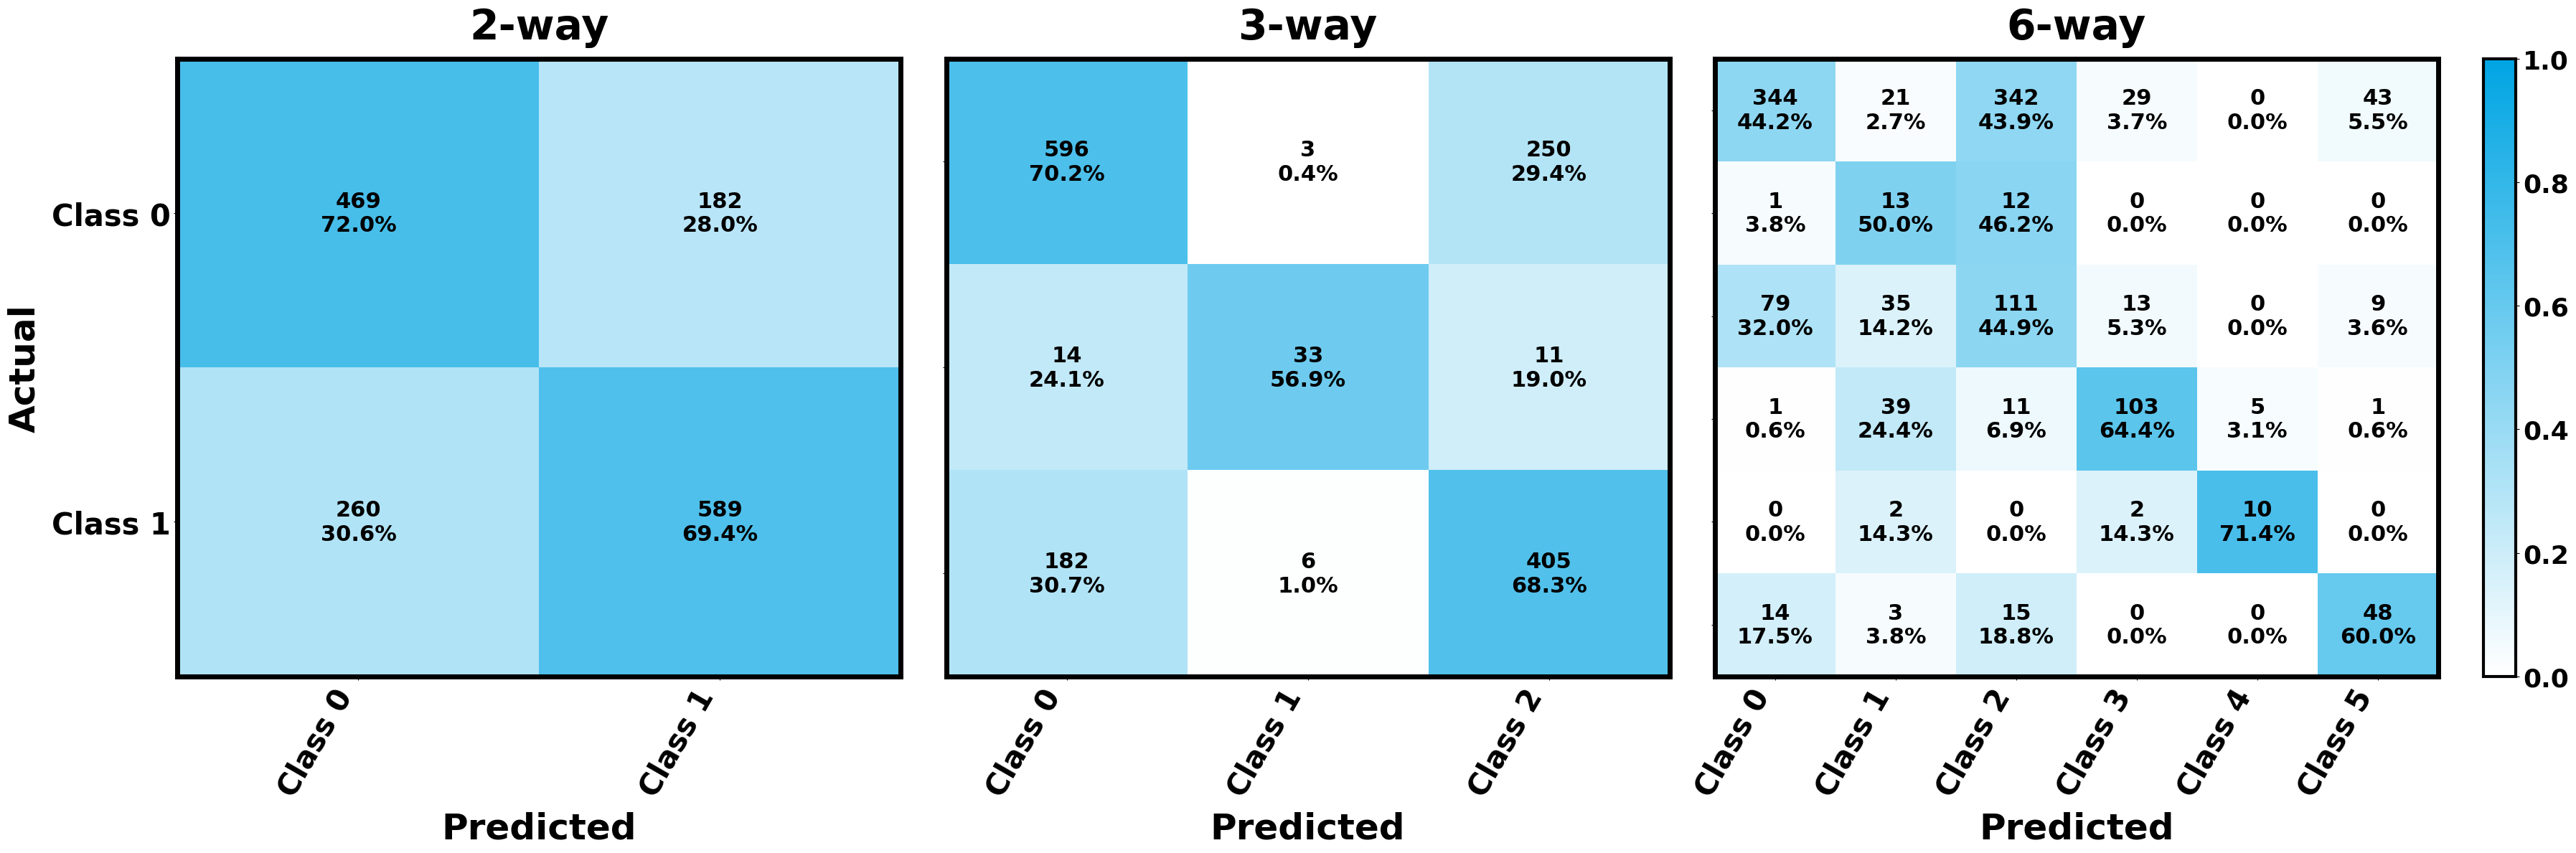

In [5]:
# Hard-coded confusion matrices
cm_2 = np.array([[469, 182],
                 [260, 589]], dtype=float)

cm_3 = np.array([[596,   3, 250],
                 [ 14,  33,  11],
                 [182,   6, 405]], dtype=float)

cm_6 = np.array([[344,  21, 342,  29,  0, 43],
                 [  1,  13,  12,   0,  0,  0],
                 [ 79,  35, 111,  13,  0,  9],
                 [  1,  39,  11, 103,  5,  1],
                 [  0,   2,   0,   2, 10,  0],
                 [ 14,   3,  15,   0,  0, 48]], dtype=float)

# ---- CONTROL COLORS HERE ----
conf_cmap = LinearSegmentedColormap.from_list(
    "my_cmap", ["#ffffff", "#00a5e3"], N=256
)

# Plot confusion matrices
plot_confusion_matrices(
    conf_mats=[cm_2, cm_3, cm_6],
    titles=["2-way", "3-way", "6-way"],
    class_names_list=[["Class 0","Class 1"],
                      ["Class 0","Class 1","Class 2"],
                      ["Class 0","Class 1","Class 2","Class 3","Class 4","Class 5"]],
    cmap=conf_cmap,
    save_path="confusion_matrices_multimodel.png"
)

In [6]:
def plot_metric_bars(
    model_labels,
    metrics_dict,
    colors,
    save_path="metrics_comparison.png"
):
    """
    Grouped bar chart comparing metrics across models.
    - model_labels: ["2-way", "3-way", "6-way"]
    - metrics_dict: {"Accuracy":[..], "Precision":[..], "Recall":[..], "F1":[..]}
    - colors: tuple/list of 3 hex codes for the models
    """
    metric_names = list(metrics_dict.keys())
    vals = [metrics_dict[m] for m in metric_names]

    x = np.arange(len(metric_names))
    n_models = len(model_labels)
    width = 0.8 / n_models

    fig, ax = plt.subplots(figsize=(24, 7))
    ax.grid(axis="y", linestyle="--", alpha=0.5)

    for j in range(n_models):
        offsets = x - 0.4 + width/2 + j * width
        y = [vals[i][j] for i in range(len(metric_names))]
        bars = ax.bar(
            offsets, y, width=width,
            color=colors[j % len(colors)],
            edgecolor="#444", linewidth=4,
            label=model_labels[j]
        )
        for b in bars:
            h = b.get_height()
            ax.text(b.get_x() + b.get_width()/2, h + 0.01, f"{h:.3f}",
                    ha="center", va="bottom", fontsize=25, color="#2b2b2b", rotation=90, fontweight="bold", )

    ax.set_xticks(x)
    ax.set_xticklabels(metric_names, fontsize=40)
    ax.set_ylabel("Score", fontsize=50)
    ax.set_ylim(0, max(1.0, max(max(v) for v in vals) + 0.1))
    ax.legend(loc="upper right", fontsize=24, frameon=True)
    ax.spines["top"].set_linewidth(4.0)
    ax.spines["bottom"].set_linewidth(4.0)
    ax.spines["left"].set_linewidth(4.0)
    ax.spines["right"].set_linewidth(4.0)

    fig.tight_layout()
    fig.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close(fig)

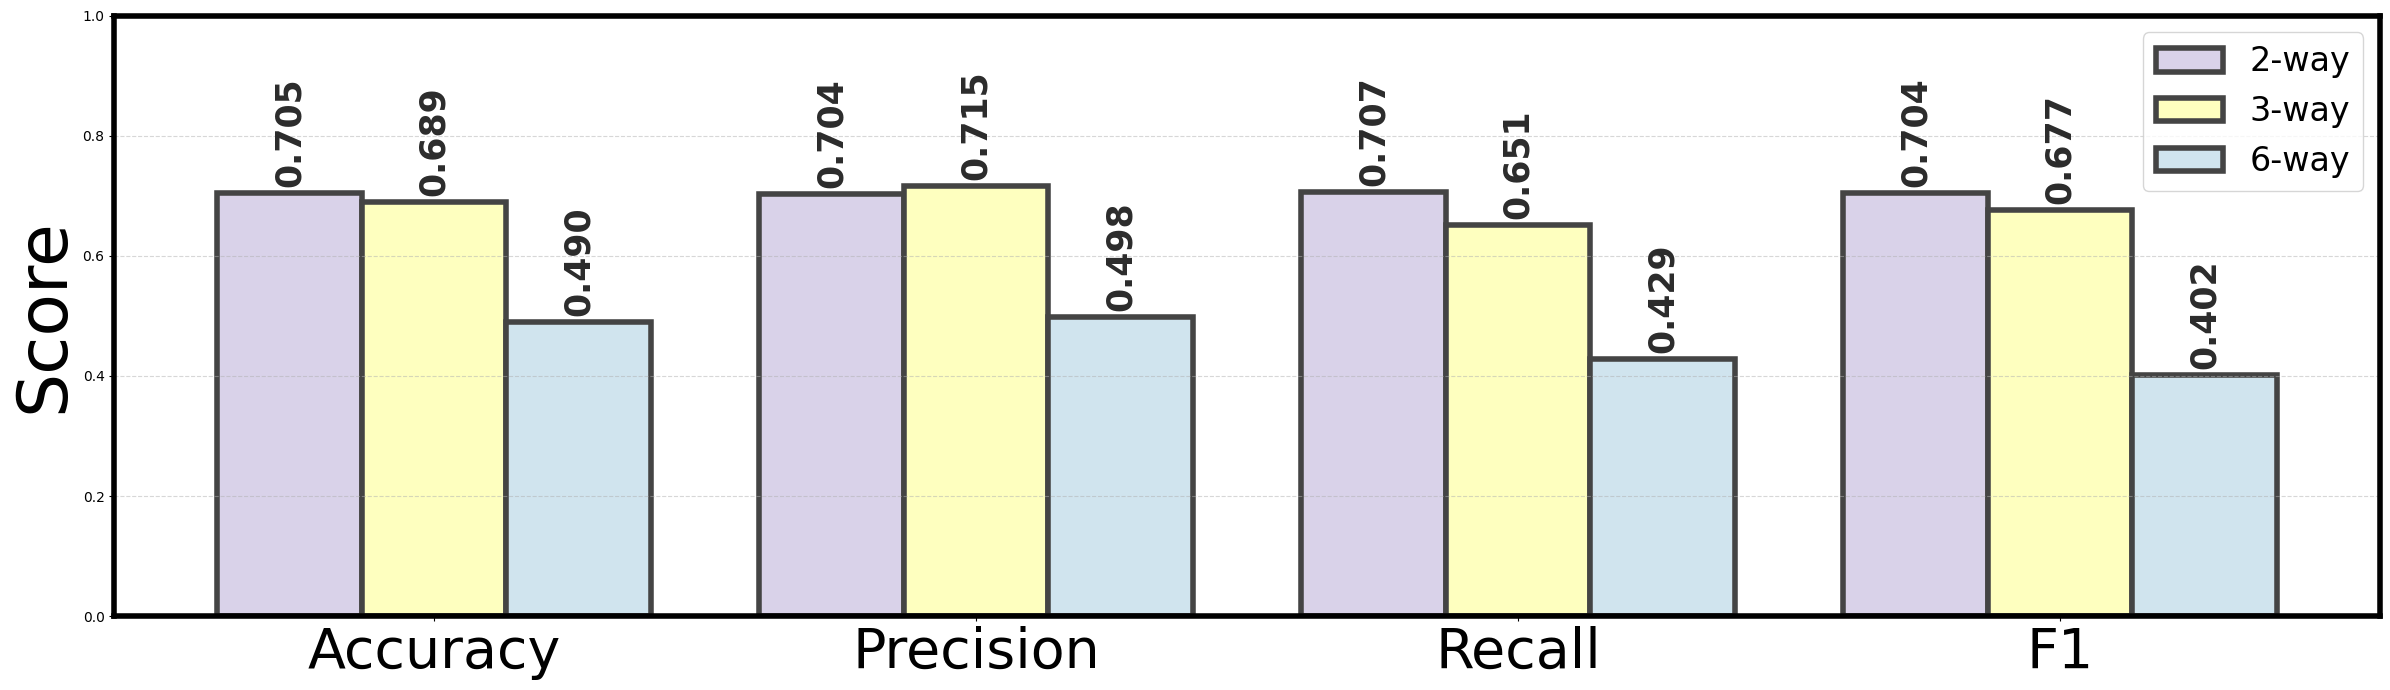

In [7]:
# ============================
# Metrics (from your images)
# ============================
model_labels = ["2-way", "3-way", "6-way"]

metrics = {
    # Accuracies from the TEST METRICS blocks
    "Accuracy":  [0.7053, 0.6893, 0.4900],

    # Macro averages from the classification reports
    "Precision": [0.7036, 0.7154, 0.4981],
    "Recall":    [0.7067, 0.6513, 0.4288],

    # For 2-way, F1 is the TEST METRICS F1-macro (0.704335… ≈ 0.7043)
    # For 3-way and 6-way, macro F1 from their classification reports
    "F1":        [0.7043, 0.6766, 0.4016],
}

bar_colors = ["#d9d2e9", "#feffbf", "#d0e4ee"]  # pastel purple, yellow, blue

plot_metric_bars(
    model_labels,
    metrics,
    colors=bar_colors,
    save_path="metrics_comparison_multimodel.png"
)